# 02 - Predicting the missing precursor charge

About 1.5 % of the cleaned spectra have no precursor-charge annotation. We
train a classifier on the annotated spectra and use it to fill the gaps.

In [11]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, classification_report
from catboost import CatBoostClassifier

import common as c

RANDOM_STATE = 42 #haha

In [12]:
spectra = pd.read_parquet("clean_spectra.parquet")
known = spectra[spectra["precursor_charge"].notna()].copy()
unknown = spectra[spectra["precursor_charge"].isna()].copy()
known["precursor_charge"] = known["precursor_charge"].astype(int)
print("annotated :", len(known))
print("to predict :", len(unknown))

known["precursor_charge"].value_counts().sort_index()

annotated : 349860
to predict : 5400


precursor_charge
2    213593
3    125112
4     10938
5       217
Name: count, dtype: int64

### Attempt #1

Basically just `predict-precursorcharge.ipynb` but refactored

In [13]:
AA_BASIC = set("KRH")
AA_ACIDIC = set("DE")

def baseline_features(row):
    seq = row["peptide_sequence"]
    clean_seq = re.sub(r"\[.*?\]", "", seq)
    intensities = np.asarray(row["intensities_raw"])
    log_int = np.log1p(intensities)
    ions = row["matched_ions"]
    b_nums, y_nums = [], []
    for ion in ions:
        if ion.startswith("b"):
            b_nums.append(int(ion[1:]))
        elif ion.startswith("y"):
            y_nums.append(int(ion[1:]))
    return {
        "length": len(clean_seq),
        "n_KRH": sum(aa in AA_BASIC for aa in clean_seq),
        "n_DE": sum(aa in AA_ACIDIC for aa in clean_seq),
        "n_b": len(b_nums),
        "n_y": len(y_nums),
        "max_b": max(b_nums) if b_nums else 0,
        "max_y": max(y_nums) if y_nums else 0,
        "int_mean": log_int.mean(),
        "int_std": log_int.std(),
        "int_max": log_int.max(),
        "int_median": np.median(log_int),
        "int_sum": log_int.sum(),
    }

def baseline_model():
    return CatBoostClassifier(
        depth=8,
        iterations=500,
        learning_rate=0.05,
        loss_function="MultiClass",
        auto_class_weights="Balanced",
        random_state=RANDOM_STATE,
        thread_count=-1,
        verbose=0,
    )

### Benchmark setup

Data is 
- fixed
- stratified K Fold
- 60k subsample 
- 3-fold stratified CV

measure
=>  macro-F1 and accuracy.

In [14]:
EVAL_N = 60_000
eval_df = known.sample(EVAL_N, random_state=RANDOM_STATE).reset_index(drop=True)
y_eval = eval_df["precursor_charge"].values

def cross_val_macro_f1(make_X, model_factory, df, y, n_splits=3):
    X = make_X(df)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    f1s, accs = [], []
    for tr, te in skf.split(X, y):
        clf = model_factory()
        clf.fit(X.iloc[tr], y[tr])
        pred = clf.predict(X.iloc[te]).ravel().astype(int)
        f1s.append(f1_score(y[te], pred, average="macro"))
        accs.append(accuracy_score(y[te], pred))
    return np.array(f1s), np.array(accs)

In [ ]:
def make_X_baseline(df):
    return pd.DataFrame(df.apply(baseline_features, axis=1).tolist())

base_f1, base_acc = cross_val_macro_f1(make_X_baseline, baseline_model, eval_df, y_eval)
print(f"BASELINE  macro-F1 = {base_f1.mean():.4f} +/- {base_f1.std():.4f}")
print(f"BASELINE  accuracy = {base_acc.mean():.4f} +/- {base_acc.std():.4f}")

### Attempt #2

Improvements:
- More Features: full peptide monoisotopic mass, basic-residue density, terminal-residue flags, the highest fragment number relative to length, and the b/y count ratio
- Hyperparameter tuning: more iterations with a
  lower learning rate, L2 regularisation, plus early-stopping headroom

In [ ]:
def improved_features(row):
    seq = row["peptide_sequence"]
    tokens = c.parse_peptide(seq)
    clean_seq = c.strip_mods(seq)
    L = len(clean_seq)
    intensities = np.asarray(row["intensities_raw"])
    log_int = np.log1p(intensities)
    ions = row["matched_ions"]
    b_nums = [int(i[1:]) for i in ions if i.startswith("b")]
    y_nums = [int(i[1:]) for i in ions if i.startswith("y")]

    mass = sum(c.AA_MONO_MASS[a] for a in clean_seq) + 18.01056
    mass += sum(c.MOD_MASS[t] for t in tokens if t in c.MOD_MASS)
    n_basic = sum(a in AA_BASIC for a in clean_seq)
    n_acid = sum(a in AA_ACIDIC for a in clean_seq)

    feats = {
        # same as #1
        "length": L,
        "n_KRH": n_basic,
        "n_DE": n_acid,
        "n_b": len(b_nums),
        "n_y": len(y_nums),
        "max_b": max(b_nums) if b_nums else 0,
        "max_y": max(y_nums) if y_nums else 0,
        "int_mean": log_int.mean(),
        "int_std": log_int.std(),
        "int_max": log_int.max(),
        "int_median": np.median(log_int),
        "int_sum": log_int.sum(),
        # extras yey
        "pep_mass": mass,
        "mass_per_len": mass / L,
        "basic_density": n_basic / L,
        "acid_density": n_acid / L,
        "n_K": clean_seq.count("K"),
        "n_R": clean_seq.count("R"),
        "n_H": clean_seq.count("H"),
        "n_P": clean_seq.count("P"),
        "nterm_basic": int(clean_seq[0] in AA_BASIC),
        "cterm_basic": int(clean_seq[-1] in AA_BASIC),
        "frag_coverage": (len(b_nums) + len(y_nums)) / max(2 * (L - 1), 1),
        "max_frag_rel": max(b_nums + y_nums + [0]) / L,
        "by_ratio": len(b_nums) / max(len(y_nums), 1),
    }
    return feats

def improved_model():
    return CatBoostClassifier(
        depth=8,
        iterations=900,
        learning_rate=0.03,
        l2_leaf_reg=6.0,
        loss_function="MultiClass",
        auto_class_weights="Balanced",
        random_state=RANDOM_STATE,
        thread_count=-1,
        verbose=0,
    )

In [ ]:
def make_X_improved(df):
    return pd.DataFrame(df.apply(improved_features, axis=1).tolist())

imp_f1, imp_acc = cross_val_macro_f1(make_X_improved, improved_model, eval_df, y_eval)
print(f"IMPROVED  macro-F1 = {imp_f1.mean():.4f} +/- {imp_f1.std():.4f}")
print(f"IMPROVED  accuracy = {imp_acc.mean():.4f} +/- {imp_acc.std():.4f}")

IMPROVED  macro-F1 = 0.7940 +/- 0.0349
IMPROVED  accuracy = 0.9880 +/- 0.0005


## Benchmarkingtime

In [ ]:
comparison = pd.DataFrame({
    "macro_f1": [base_f1.mean(), imp_f1.mean()],
    "macro_f1_std": [base_f1.std(), imp_f1.std()],
    "accuracy": [base_acc.mean(), imp_acc.mean()],
}, index=["baseline", "improved"])
comparison["macro_f1_delta"] = comparison["macro_f1"] - base_f1.mean()

comparison.round(4).to_string()

          macro_f1  macro_f1_std  accuracy  macro_f1_delta
baseline    0.7648        0.0398    0.9846          0.0000
improved    0.7940        0.0349    0.9880          0.0292

improved model wins: True


### Doing it for the plot

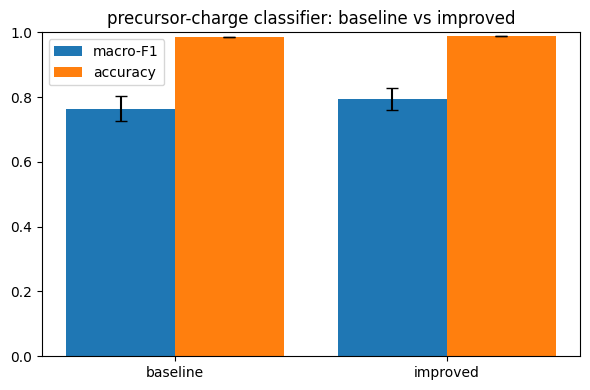

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(2)
ax.bar(x - 0.2, [base_f1.mean(), imp_f1.mean()], 0.4,
       yerr=[base_f1.std(), imp_f1.std()], capsize=4, label="macro-F1")
ax.bar(x + 0.2, [base_acc.mean(), imp_acc.mean()], 0.4,
       yerr=[base_acc.std(), imp_acc.std()], capsize=4, label="accuracy")
ax.set_xticks(x); ax.set_xticklabels(["baseline", "improved"])
ax.set_ylim(0, 1); ax.set_title("precursor-charge classifier: baseline vs improved")
ax.legend(); plt.tight_layout(); plt.show()

## Training the improved model with the full data

In [ ]:
make_X = make_X_improved
model_factory = improved_model

# Held-out report on a stratified split for a per-class view.
from sklearn.model_selection import train_test_split
tr_df, te_df = train_test_split(
    known, test_size=0.15, stratify=known["precursor_charge"], random_state=RANDOM_STATE
)
clf = model_factory()
clf.fit(make_X(tr_df), tr_df["precursor_charge"].values)
te_pred = clf.predict(make_X(te_df)).ravel().astype(int)
print(classification_report(te_df["precursor_charge"].values, te_pred))

using: improved


              precision    recall  f1-score   support

           2       1.00      1.00      1.00     32039
           3       0.99      0.98      0.99     18767
           4       0.82      0.97      0.89      1641
           5       0.53      0.78      0.63        32

    accuracy                           0.99     52479
   macro avg       0.84      0.93      0.88     52479
weighted avg       0.99      0.99      0.99     52479



In [ ]:
# Final fit
final_clf = model_factory()
final_clf.fit(make_X(known), known["precursor_charge"].values)

imputed_charge = final_clf.predict(make_X(unknown)).ravel().astype(int)
print("imputed charge distribution:")
print(pd.Series(imputed_charge).value_counts().sort_index())

imputed charge distribution:
2    3418
3    1594
4     377
5      11
Name: count, dtype: int64


### Augment data and write to disk

In [ ]:
known_out = known.copy()
known_out["charge_source"] = "annotated"
unknown_out = unknown.copy()
unknown_out["precursor_charge"] = imputed_charge
unknown_out["charge_source"] = "predicted"

full = pd.concat([known_out, unknown_out], ignore_index=True)
full["precursor_charge"] = full["precursor_charge"].astype(int)
assert full["precursor_charge"].notna().all()
full.to_parquet("spectra_with_charge.parquet", index=False)
print("wrote spectra_with_charge.parquet:", full.shape)
print(full["charge_source"].value_counts())

wrote spectra_with_charge.parquet: (355260, 8)
charge_source
annotated    349860
predicted      5400
Name: count, dtype: int64
